In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('./resources/12_Churn_Modelling.csv')

In [3]:
print(df.shape)
df.head()

(10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.drop(inplace=True ,columns=['RowNumber' ,'CustomerId','Surname' ] )

In [6]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [8]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [9]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [10]:
df = pd.get_dummies(df,columns=['Geography','Gender'], drop_first=True)

In [11]:
cols = ["Geography_Germany", "Geography_Spain", "Gender_Male"]
df[cols] = df[cols].astype(int)

In [12]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,1,0,1


In [13]:
X = df.drop(columns=['Exited'])
y = df['Exited']

x_train , x_test , y_train , y_test = train_test_split(X ,y)


In [14]:
print(x_train.shape , y_train.shape)

(7500, 11) (7500,)


In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.fit_transform(x_test)


In [16]:
x_train_scaled

array([[ 0.40156915, -0.55813839, -1.0498018 , ...,  1.72103606,
        -0.57119169,  0.92023679],
       [ 0.04954196,  0.48554839,  0.33418721, ...,  1.72103606,
        -0.57119169, -1.08667683],
       [-0.69592738, -1.12742209, -0.35780729, ...,  1.72103606,
        -0.57119169,  0.92023679],
       ...,
       [-1.7416552 ,  1.52923518, -0.01181004, ..., -0.58104535,
        -0.57119169,  0.92023679],
       [ 0.10131066, -0.36837716,  0.68018447, ..., -0.58104535,
        -0.57119169,  0.92023679],
       [-0.69592738, -1.60182518, -1.0498018 , ..., -0.58104535,
         1.75072575, -1.08667683]], shape=(7500, 11))

In [17]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense


In [36]:
model = Sequential()

model.add(Dense(11 , activation='relu', input_dim=11))
model.add(Dense(11 , activation='relu'))
model.add(Dense(1, activation='sigmoid'))

c:\Users\Meet\Desktop\AgenticAI\venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
model.compile(loss='binary_crossentropy' , optimizer='Adam' , metrics=['accuracy'])


In [39]:
history = model.fit(x_train_scaled,y_train , epochs=50 , validation_split=0.2)

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7710 - loss: 0.5570 - val_accuracy: 0.7987 - val_loss: 0.4887
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7975 - loss: 0.4660 - val_accuracy: 0.7987 - val_loss: 0.4505
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8000 - loss: 0.4367 - val_accuracy: 0.8040 - val_loss: 0.4309
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8135 - loss: 0.4184 - val_accuracy: 0.8180 - val_loss: 0.4195
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8290 - loss: 0.4029 - val_accuracy: 0.8260 - val_loss: 0.4066
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8397 - loss: 0.3865 - val_accuracy: 0.8313 - val_loss: 0.3935
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8460 - loss: 0.3722 - val_accuracy: 0.8353 - val_loss: 0.3806
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8503 - loss: 0.3599 - val_accuracy: 0.

In [40]:
model.layers[2].get_weights()

[array([[ 0.30541506],
        [-0.5081681 ],
        [-0.6928656 ],
        [-0.6316986 ],
        [-0.3050079 ],
        [ 0.94712985],
        [ 0.79478025],
        [-0.8768783 ],
        [-0.62047327],
        [-1.1334748 ],
        [ 0.92008764]], dtype=float32),
 array([-0.05544092], dtype=float32)]

In [41]:
y_log = model.predict(X_test_scaled)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [42]:
y_pred = np.where(y_log>0.5,1,0)

In [43]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test , y_pred)

0.856

In [44]:
import matplotlib.pyplot as plt

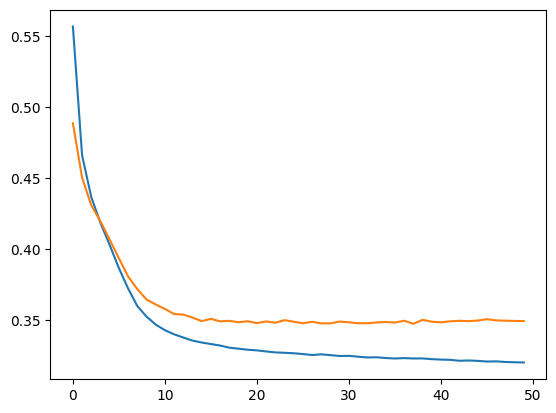

In [45]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

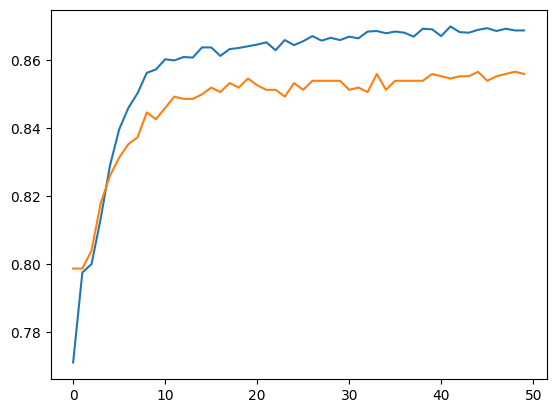

In [46]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])